In [1]:
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv("../data/store_operations.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Extract useful time columns
df["hour"] = df["timestamp"].dt.hour
df["day_name"] = df["timestamp"].dt.day_name()

# Preview data
df.head()

,timestamp,customers,revenue,transactions,avg_order_value,predicted_sales,labour_cost,staff_count,avg_wait_time,drive_thru_time,labour_efficiency,sales_vs_prediction_diff,hour,day_name
0,2026-01-01 00:00:00,5,36.68,4,8.98,33.37,26.34,2,3.99,5.78,1.39,3.31,0,Thursday
1,2026-01-01 01:00:00,13,75.27,12,6.76,78.04,24.17,2,2.67,5.55,3.11,-2.77,1,Thursday
2,2026-01-01 02:00:00,11,68.42,8,8.88,62.02,27.08,2,2.26,4.24,2.53,6.40,2,Thursday
3,2026-01-01 03:00:00,12,78.90,11,7.42,76.85,29.29,2,2.02,5.42,2.69,2.05,3,Thursday
4,2026-01-01 04:00:00,5,34.21,4,8.62,35.15,28.73,2,3.21,4.94,1.19,-0.94,4,Thursday


In [2]:
hourly_sales = (
    df.groupby("hour")["revenue"]
    .mean()
    .reset_index()
)

hourly_sales

,hour,revenue
0,0,101.548667
1,1,96.525444
2,2,102.639111
3,3,103.538444
4,4,101.382889
5,5,97.743333
6,6,156.667000
7,7,573.206889
8,8,584.042000
9,9,588.741111


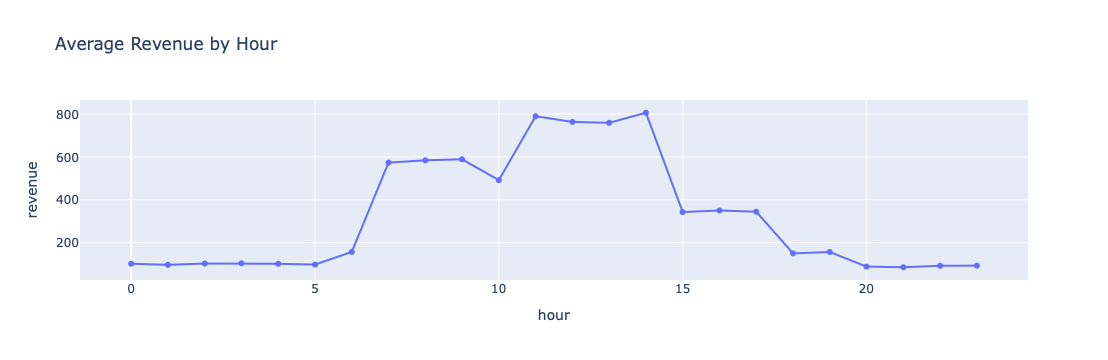

In [3]:
fig = px.line(
    hourly_sales,
    x="hour",
    y="revenue",
    title="Average Revenue by Hour",
    markers=True
)

fig.show()

In [4]:
hourly_customers = (
    df.groupby("hour")["customers"]
    .mean()
    .reset_index()
)

hourly_customers

,hour,customers
0,0,13.800000
1,1,13.755556
2,2,14.255556
3,3,13.944444
4,4,14.055556
5,5,14.166667
6,6,22.022222
7,7,66.700000
8,8,65.811111
9,9,66.711111


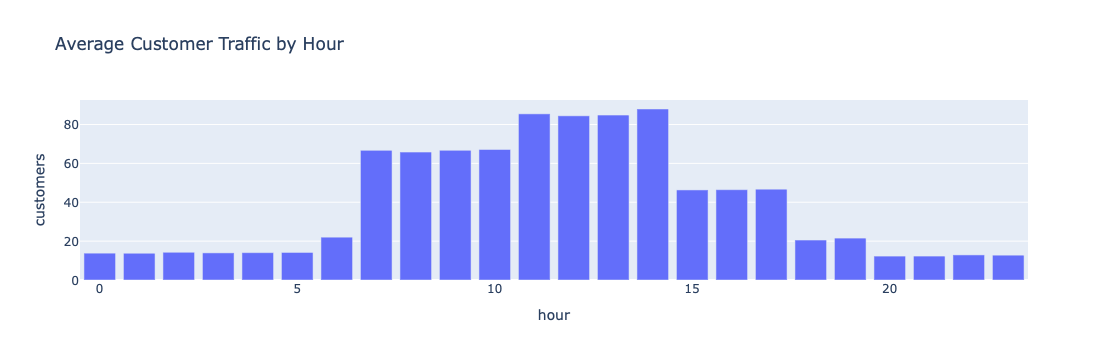

In [5]:
fig = px.bar(
    hourly_customers,
    x="hour",
    y="customers",
    title="Average Customer Traffic by Hour"
)

fig.show()

In [6]:
df["labour_efficiency"] = (
    df["revenue"] / df["labour_cost"]
).round(2)

df.head()

,timestamp,customers,revenue,transactions,avg_order_value,predicted_sales,labour_cost,staff_count,avg_wait_time,drive_thru_time,labour_efficiency,sales_vs_prediction_diff,hour,day_name
0,2026-01-01 00:00:00,5,36.68,4,8.98,33.37,26.34,2,3.99,5.78,1.39,3.31,0,Thursday
1,2026-01-01 01:00:00,13,75.27,12,6.76,78.04,24.17,2,2.67,5.55,3.11,-2.77,1,Thursday
2,2026-01-01 02:00:00,11,68.42,8,8.88,62.02,27.08,2,2.26,4.24,2.53,6.40,2,Thursday
3,2026-01-01 03:00:00,12,78.90,11,7.42,76.85,29.29,2,2.02,5.42,2.69,2.05,3,Thursday
4,2026-01-01 04:00:00,5,34.21,4,8.62,35.15,28.73,2,3.21,4.94,1.19,-0.94,4,Thursday


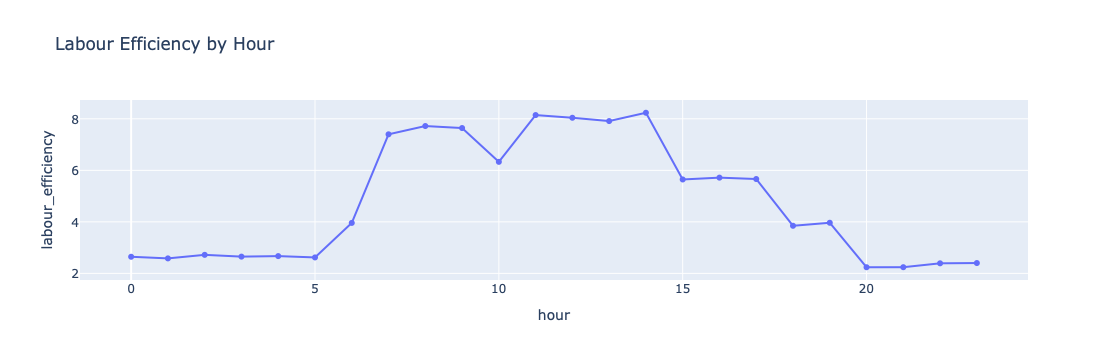

In [7]:
labour_efficiency = (
    df.groupby("hour")["labour_efficiency"]
    .mean()
    .reset_index()
)

fig = px.line(
    labour_efficiency,
    x="hour",
    y="labour_efficiency",
    title="Labour Efficiency by Hour",
    markers=True
)

fig.show()

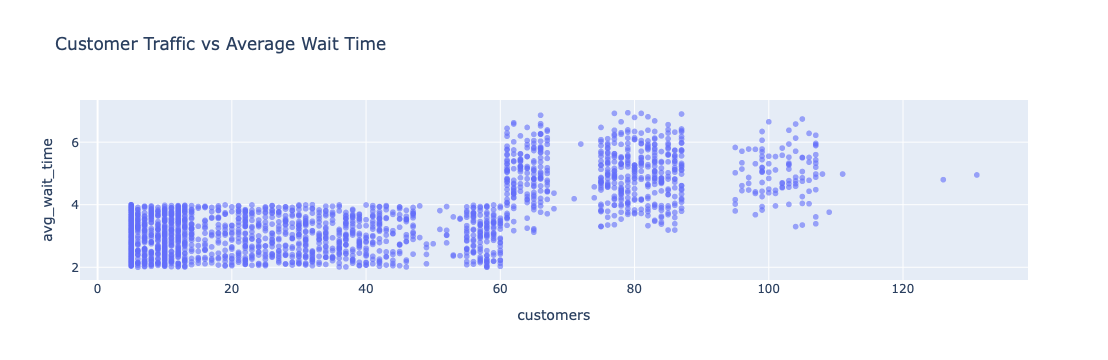

In [8]:
fig = px.scatter(
    df,
    x="customers",
    y="avg_wait_time",
    title="Customer Traffic vs Average Wait Time",
    opacity=0.6
)

fig.show()

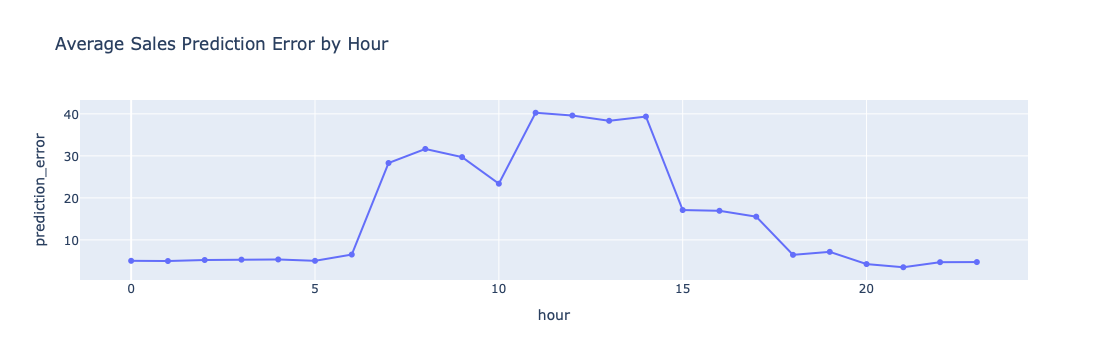

In [9]:
df["prediction_error"] = abs(
    df["revenue"] - df["predicted_sales"]
)

prediction_analysis = (
    df.groupby("hour")["prediction_error"]
    .mean()
    .reset_index()
)

fig = px.line(
    prediction_analysis,
    x="hour",
    y="prediction_error",
    title="Average Sales Prediction Error by Hour",
    markers=True
)

fig.show()

In [10]:
low_efficiency = df[
    df["labour_efficiency"] < 5
]

low_efficiency.head()

,timestamp,customers,revenue,transactions,avg_order_value,predicted_sales,labour_cost,staff_count,avg_wait_time,drive_thru_time,labour_efficiency,sales_vs_prediction_diff,hour,day_name,prediction_error
0,2026-01-01 00:00:00,5,36.68,4,8.98,33.37,26.34,2,3.99,5.78,1.39,3.31,0,Thursday,3.31
1,2026-01-01 01:00:00,13,75.27,12,6.76,78.04,24.17,2,2.67,5.55,3.11,-2.77,1,Thursday,2.77
2,2026-01-01 02:00:00,11,68.42,8,8.88,62.02,27.08,2,2.26,4.24,2.53,6.40,2,Thursday,6.40
3,2026-01-01 03:00:00,12,78.90,11,7.42,76.85,29.29,2,2.02,5.42,2.69,2.05,3,Thursday,2.05
4,2026-01-01 04:00:00,5,34.21,4,8.62,35.15,28.73,2,3.21,4.94,1.19,-0.94,4,Thursday,0.94


## Key Operational Insights

- Lunch periods generate the highest revenue.
- Labour efficiency decreases during low-traffic evening hours.
- Increased customer traffic significantly impacts wait times.
- Forecast variance is highest during peak operational periods.